In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
DATA_PATH = r'D:\Machine Learning\taobao_behaviour\ECommerce_consumer_behaviour.csv'

# 1. Load du lieu tho

In [3]:
df = pd.read_csv(DATA_PATH)
df.head()

C:\Users\Dell\AppData\Local\Temp\ipykernel_17968\2006162025.py:1: DtypeWarning: Columns (0: order_hour_of_day) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(DATA_PATH)


,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_id,add_to_cart_order,reordered,department_id,department,product_name
0,2425083,49125,1,2,18,NaN,17,1,0,13,pantry,baking ingredients
1,2425083,49125,1,2,,NaN,91,2,0,16,dairy eggs,soy lactosefree
2,2425083,49125,1,2,18,NaN,36,3,0,16,dairy eggs,butter
3,2425083,49125,1,2,18,NaN,83,4,0,4,produce,fresh vegetables
4,2425083,49125,1,2,18,NaN,83,5,0,4,produce,fresh vegetables


In [4]:
df.shape

(1048575, 12)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 12 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   order_id                1048575 non-null  int64  
 1   user_id                 1048575 non-null  int64  
 2   order_number            1048575 non-null  int64  
 3   order_dow               1048575 non-null  int64  
 4   order_hour_of_day       1048575 non-null  object 
 5   days_since_prior_order  983854 non-null   float64
 6   product_id              1048575 non-null  int64  
 7   add_to_cart_order       1048575 non-null  int64  
 8   reordered               1048575 non-null  int64  
 9   department_id           1048575 non-null  int64  
 10  department              1048575 non-null  str    
 11  product_name            1048575 non-null  str    
dtypes: float64(1), int64(8), object(1), str(2)
memory usage: 118.4+ MB


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.columns

Index(['order_id', 'user_id', 'order_number', 'order_dow', 'order_hour_of_day',
       'days_since_prior_order', 'product_id', 'add_to_cart_order',
       'reordered', 'department_id', 'department', 'product_name'],
      dtype='str')

# 2. Kiem tra cha luong du lieu

In [8]:
print('Giá trị order_hour_of_day bất thường (không parse được thành số):')
tmp = df['order_hour_of_day'].str.strip()
bad_mask = pd.to_numeric(tmp, errors='coerce').isna()
print(df.loc[bad_mask, 'order_hour_of_day'].value_counts())

Giá trị order_hour_of_day bất thường (không parse được thành số):
order_hour_of_day
10    85322
11    83172
15    81414
14    81261
13    81230
12    79662
16    76563
9     72977
17    63261
8     51816
18    49329
19    39184
20    29838
7     26207
21    23908
22    18975
23    12493
6      8943
0      6485
1      3307
5      2665
2      2193
4      1531
3      1303
          1
Name: count, dtype: int64


In [9]:
# Missing values
missing = df.isnull().sum()
missing = missing[missing > 0]
print('Cột có missing values:')
print(missing)
print()
print('days_since_prior_order missing đúng bằng số đơn hàng đầu tiên (order_number == 1) của mỗi user?')
first_orders = (df.drop_duplicates('order_id')['order_number'] == 1).sum()
print('Số order có order_number==1:', first_orders)
print('Số dòng missing days_since_prior_order:', df['days_since_prior_order'].isna().sum())
print('-> Về bản chất đây là missing hợp lý (đơn đầu tiên thì không có "khoảng cách với đơn trước").')

Cột có missing values:
days_since_prior_order    64721
dtype: int64

days_since_prior_order missing đúng bằng số đơn hàng đầu tiên (order_number == 1) của mỗi user?
Số order có order_number==1: 6344
Số dòng missing days_since_prior_order: 64721
-> Về bản chất đây là missing hợp lý (đơn đầu tiên thì không có "khoảng cách với đơn trước").


In [10]:
print('Số dòng trùng lặp hoàn toàn:', df.duplicated().sum())
print('Số order_id duy nhất:', df['order_id'].nunique())
print('Số user_id duy nhất:', df['user_id'].nunique())
print('Số product_id duy nhất:', df['product_id'].nunique())
print('Trung bình số đơn hàng ĐƯỢC GHI NHẬN trong file / user:', (df.groupby('user_id')['order_id'].nunique()).mean().round(2))

Số dòng trùng lặp hoàn toàn: 0
Số order_id duy nhất: 103761
Số user_id duy nhất: 70268
Số product_id duy nhất: 134
Trung bình số đơn hàng ĐƯỢC GHI NHẬN trong file / user: 1.48


In [11]:
df.describe(include='all')

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_id,add_to_cart_order,reordered,department_id,department,product_name
count,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1048575.0,983854.000000,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1048575,1048575
unique,NaN,NaN,NaN,NaN,49.0,NaN,NaN,NaN,NaN,NaN,21,134
top,NaN,NaN,NaN,NaN,10.0,NaN,NaN,NaN,NaN,NaN,produce,fresh fruits
freq,NaN,NaN,NaN,NaN,85322.0,NaN,NaN,NaN,NaN,NaN,305964,117506
mean,1.704987e+06,1.029952e+05,1.719931e+01,2.728710e+00,NaN,11.431402,7.119057e+01,8.370037e+00,5.888096e-01,9.928045e+00,NaN,NaN
std,9.867587e+05,5.952690e+04,1.757635e+01,2.095244e+00,NaN,8.995322,3.818826e+01,7.134039e+00,4.920499e-01,6.288690e+00,NaN,NaN
min,1.100000e+01,3.000000e+00,1.000000e+00,0.000000e+00,NaN,0.000000,1.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,NaN,NaN
25%,8.493110e+05,5.139400e+04,5.000000e+00,1.000000e+00,NaN,5.000000,3.100000e+01,3.000000e+00,0.000000e+00,4.000000e+00,NaN,NaN
50%,1.702748e+06,1.024560e+05,1.100000e+01,3.000000e+00,NaN,8.000000,8.300000e+01,6.000000e+00,1.000000e+00,9.000000e+00,NaN,NaN
75%,2.557490e+06,1.546710e+05,2.400000e+01,5.000000e+00,NaN,15.000000,1.070000e+02,1.100000e+01,1.000000e+00,1.600000e+01,NaN,NaN


**Phát hiện quan trọng:** trung bình mỗi user chỉ có ~1.5 đơn hàng xuất hiện trong file (median = 1, max = 10), trong khi `order_number` của các đơn này trải dài từ 1 đến 100. Điều này cho thấy đây là một **mẫu (sample) các đơn hàng** được lấy ra từ lịch sử mua sắm đầy đủ của từng user, **không phải chuỗi liên tục**. `order_number` vẫn phản ánh đúng "đơn này là đơn thứ mấy trong vòng đời của user" nên vẫn dùng được làm trục thời gian tương đối, nhưng ta không có chuỗi hành vi liên tục cho từng user.

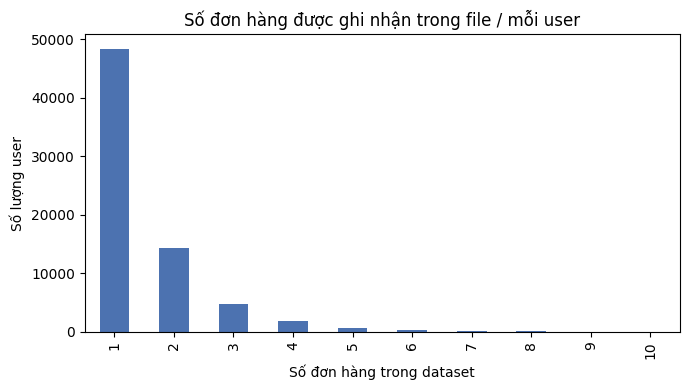

In [12]:
orders_per_user = df.groupby('user_id')['order_id'].nunique()
fig, ax = plt.subplots(figsize=(7,4))
orders_per_user.value_counts().sort_index().plot(kind='bar', ax=ax, color='#4C72B0')
ax.set_title('Số đơn hàng được ghi nhận trong file / mỗi user')
ax.set_xlabel('Số đơn hàng trong dataset')
ax.set_ylabel('Số lượng user')
plt.tight_layout()
plt.show()

# 3. Làm sạch dữ liệu

In [13]:
df_clean = df.copy()

# 3.1 Chuẩn hoá order_hour_of_day về numeric, loại bỏ dòng lỗi 
df_clean['order_hour_of_day'] = pd.to_numeric(df_clean['order_hour_of_day'], errors='coerce')
before = len(df_clean)
df_clean.dropna(subset=['order_hour_of_day'],inplace=True)
print(f'Loại bỏ {before - len(df_clean)} dòng có order_hour_of_day không hợp lệ')

# 3.2 Kiểm tra khoảng giá trị hợp lệ
assert df_clean['order_hour_of_day'].between(0, 23).all()
assert df_clean['order_dow'].between(0, 6).all()
assert (df_clean['add_to_cart_order'] >= 1).all()
assert df_clean['reordered'].isin([0, 1]).all()

print('Shape sau khi làm sạch:', df_clean.shape)

Loại bỏ 1 dòng có order_hour_of_day không hợp lệ
Shape sau khi làm sạch: (1048574, 12)


In [14]:
df_clean['department'].unique()

<ArrowStringArray>
[         'pantry',      'dairy eggs',         'produce',    'canned goods',
    'meat seafood',          'frozen',          'bakery',       'beverages',
       'breakfast',          'snacks',   'international',       'household',
   'personal care',          'babies',            'deli', 'dry goods pasta',
         'missing',         'alcohol',            'pets',            'bulk',
           'other']
Length: 21, dtype: str

data ở dạng instacart (mỗi dòng 1 sản phẩm trong 1 đơn hàng)
ta cần chuyển dữ liệu từ mức sản phẩm (product-level) sang mức đơn hàng (order-level)

In [15]:
# Lưu bảng ở mức order (mỗi order 1 dòng) để dùng cho các bước sau
order_lvl = df_clean.groupby('order_id').agg(
    user_id=('user_id', 'first'),
    order_number=('order_number', 'first'),
    order_dow=('order_dow', 'first'),
    order_hour_of_day=('order_hour_of_day', 'first'),
    days_since_prior_order=('days_since_prior_order', 'first'),
    basket_size=('product_id', 'count'),
    reorder_rate=('reordered', 'mean'),
).reset_index()

print('Số đơn hàng (order-level):', order_lvl.shape)
order_lvl.head()

Số đơn hàng (order-level): (103761, 8)


,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,basket_size,reorder_rate
0,11,143742,4,1,19.0,23.0,5,1.000000
1,64,5430,8,0,16.0,6.0,5,1.000000
2,110,73241,1,0,15.0,NaN,10,0.000000
3,192,189954,44,5,14.0,8.0,15,0.466667
4,205,190709,14,4,14.0,6.0,3,1.000000


# 4. EDA - Trực quan hóa & Insight khám phá

### 4.1 Phân phối kích thước giỏ hàng (basket size)

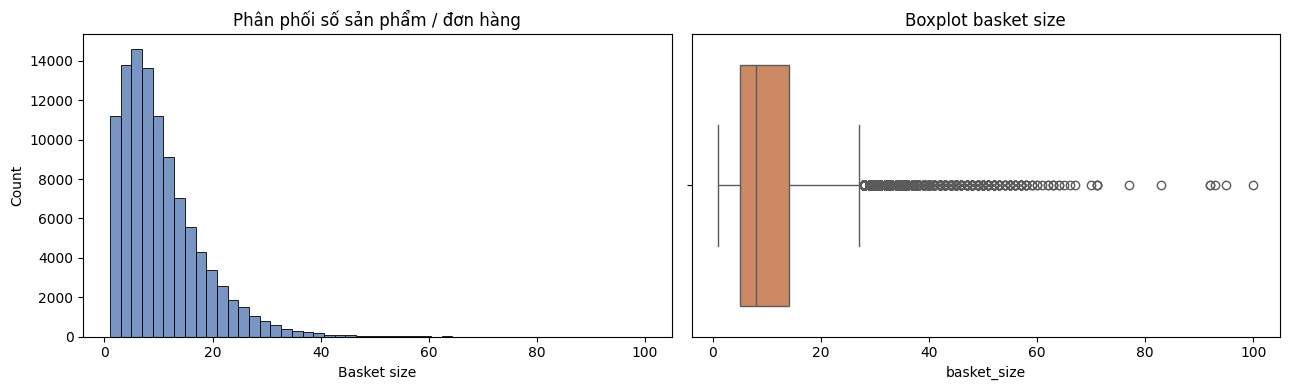

count    103761.000000
mean         10.105666
std           7.545859
min           1.000000
25%           5.000000
50%           8.000000
75%          14.000000
max         100.000000
Name: basket_size, dtype: float64


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(order_lvl['basket_size'], bins=50, ax=axes[0], color='#4C72B0')
axes[0].set_title('Phân phối số sản phẩm / đơn hàng')
axes[0].set_xlabel('Basket size')

sns.boxplot(x=order_lvl['basket_size'], ax=axes[1], color='#DD8452')
axes[1].set_title('Boxplot basket size')
plt.tight_layout()
plt.show()

print(order_lvl['basket_size'].describe())

### 4.2 Nhịp mua sắm theo ngày trong tuần và giờ trong ngày

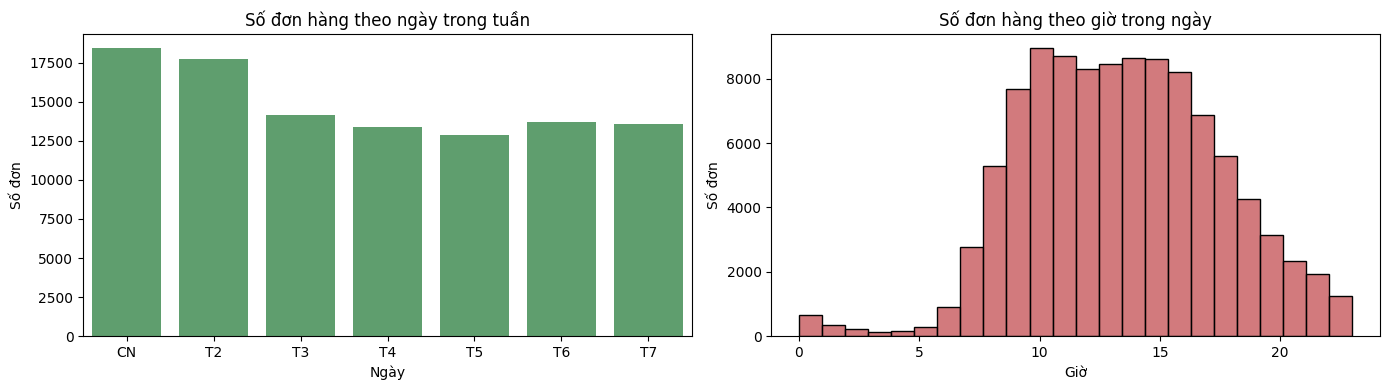

In [17]:
dow_names = {0:'CN',1:'T2',2:'T3',3:'T4',4:'T5',5:'T6',6:'T7'}
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

order_counts_dow = order_lvl['order_dow'].map(dow_names).value_counts().reindex([dow_names[i] for i in range(7)])
sns.barplot(x=order_counts_dow.index, y=order_counts_dow.values, ax=axes[0], color='#55A868')
axes[0].set_title('Số đơn hàng theo ngày trong tuần')
axes[0].set_xlabel('Ngày'); axes[0].set_ylabel('Số đơn')

sns.histplot(order_lvl['order_hour_of_day'], bins=24, ax=axes[1], color='#C44E52')
axes[1].set_title('Số đơn hàng theo giờ trong ngày')
axes[1].set_xlabel('Giờ'); axes[1].set_ylabel('Số đơn')
plt.tight_layout()
plt.show()

=> Đơn hàng tập trung mạnh nhất vào khung giờ 10h-17h, giảm mạnh về đêm  
=> cuối tuần và đầu tuần (T2) có xu hướng nhỉn hơn ngày thường -> người tiêu dung mua hàng nhiều hơn khi rảnh

### 4.3 Cơ cấu ngành hàng (department) - sản phẩm nào được mua nhiều nhất

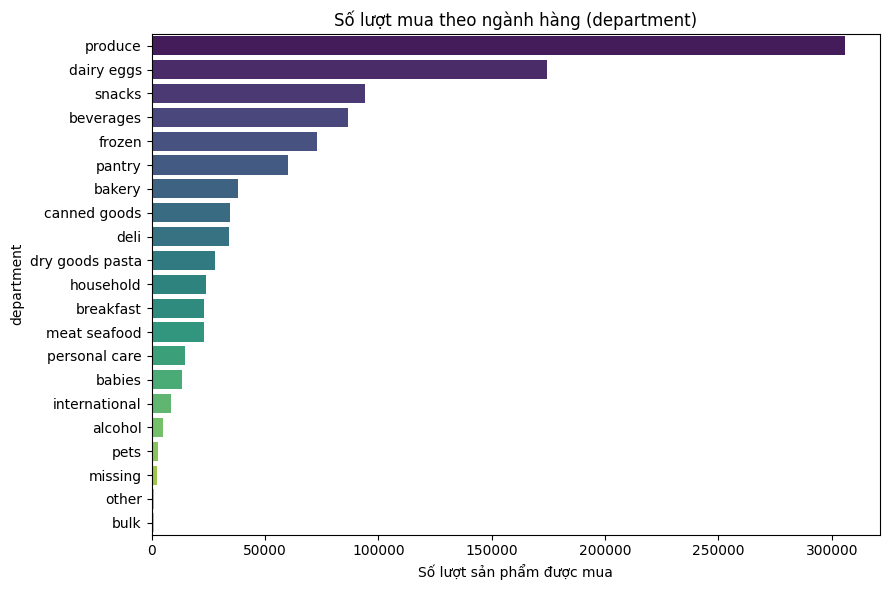

Top 5 ngành hàng chiếm 70.0 % tổng lượt mua


In [18]:
dept_counts = df_clean['department'].value_counts()
fig, ax = plt.subplots(figsize=(9,6))
sns.barplot(x=dept_counts.values, y=dept_counts.index, ax=ax, palette='viridis', hue=dept_counts.index, legend=False)
ax.set_title('Số lượt mua theo ngành hàng (department)')
ax.set_xlabel('Số lượt sản phẩm được mua')
plt.tight_layout()
plt.show()

print('Top 5 ngành hàng chiếm', round(dept_counts.head(5).sum() / dept_counts.sum() * 100, 1), '% tổng lượt mua')

Produce và dairy eggs áp đảo hoàn toàn, chiếm gần một nửa tổng số lượt mua, đây là mặt hàng thiết yếu, tần suất mua cao


### 4.4 Tỷ lệ tái mua (reorder rate) theo ngành hàng

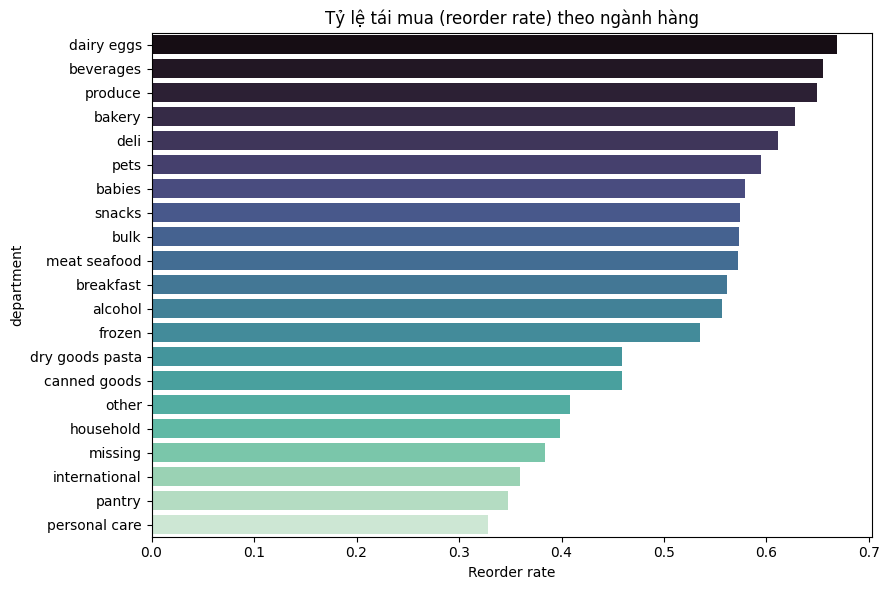

In [19]:
reorder_by_dept = df_clean.groupby('department')['reordered'].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(9,6))
sns.barplot(x=reorder_by_dept.values, y=reorder_by_dept.index, ax=ax, palette='mako', hue=reorder_by_dept.index, legend=False)
ax.set_title('Tỷ lệ tái mua (reorder rate) theo ngành hàng')
ax.set_xlabel('Reorder rate')
plt.tight_layout()
plt.show()

`dairy eggs`, `produce`, `breakfast`, `beverages` có tỷ lệ tái mua cao nhất — đúng như kỳ vọng với các mặt hàng tiêu dùng lặp lại theo chu kỳ ngắn (sữa, trứng, rau, đồ uống). Ngược lại `babies`, `household`, `personal care`, `other` có tỷ lệ tái mua thấp hơn — mua theo nhu cầu phát sinh, ít lặp lại.

### 4.5 Mối quan hệ giữa order_number & behavior

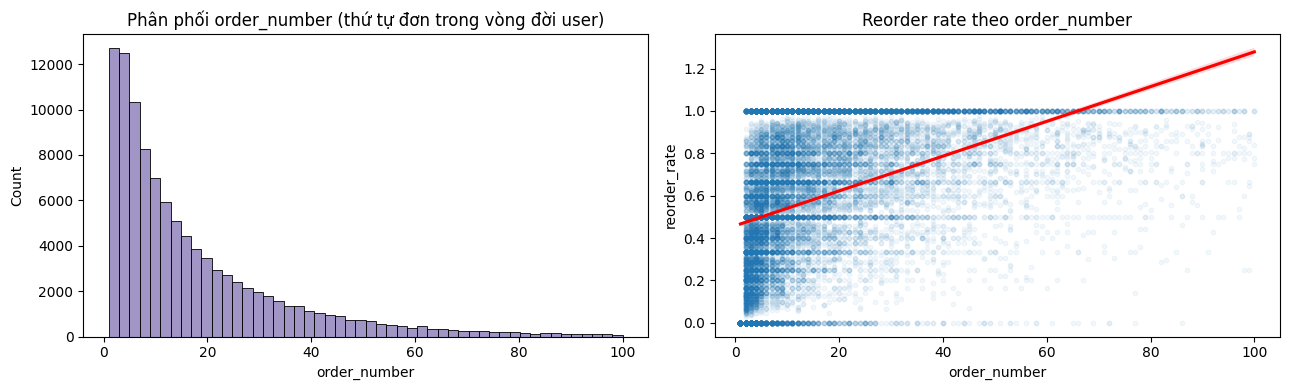

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13,4))
sns.histplot(order_lvl['order_number'], bins=50, ax=axes[0], color='#8172B2')
axes[0].set_title('Phân phối order_number (thứ tự đơn trong vòng đời user)')

order_lvl_sorted = order_lvl.sort_values('order_number')
sns.regplot(data=order_lvl_sorted.sample(min(20000, len(order_lvl_sorted)), random_state=42),
            x='order_number', y='reorder_rate', ax=axes[1], scatter_kws={'alpha':0.05, 's':10}, line_kws={'color':'red'})
axes[1].set_title('Reorder rate theo order_number')
plt.tight_layout()
plt.show()

+ phân phối order_number lệch trái, phần lớn khách hàng chỉ có số lượng đơn hàng thấp, trong khi một nhóm nhỏ là khách hàng trung thành với rất nhiều đơn mua.  
+ tỷ lệ tái mua tăng dần theo `order_number`: Reorder rate có xu hướng tăng theo order_number, cho thấy khách hàng càng gắn bó với nền tảng thì càng có xu hướng mua lại các sản phẩm quen thuộc.  
+ Độ phân tán của reorder_rate vẫn lớn ở mọi mức order_number, chứng tỏ hành vi mua lại còn chịu ảnh hưởng của nhiều yếu tố khác ngoài số lần mua.

## 5. Lưu dữ liệu đã làm sạch cho các bước tiếp theo


In [21]:
import os
os.makedirs('data', exist_ok=True)

df_clean.to_parquet('data/cleaned_items.parquet', index=False)
order_lvl.to_parquet('data/order_level.parquet', index=False)

print('Đã lưu:')
print(' - data/cleaned_items.parquet  (mức sản phẩm-trong-đơn, đã làm sạch):', df_clean.shape)
print(' - data/order_level.parquet    (mức đơn hàng, đã tổng hợp)         :', order_lvl.shape)

Đã lưu:
 - data/cleaned_items.parquet  (mức sản phẩm-trong-đơn, đã làm sạch): (1048574, 12)
 - data/order_level.parquet    (mức đơn hàng, đã tổng hợp)         : (103761, 8)
